# MOBILE-SAM FLASK BACKEND (Windows Compatible)

**Instructions:**
1. Run each cell sequentially
2. The server will start on `http://localhost:5000`
3. Test the endpoints using the test cells at the bottom

## Cell 1: Download Sample Image

In [1]:
import os
import urllib.request

# Download sample image for testing
image_url = "https://images.unsplash.com/photo-1614035030394-b6e5b01e0737?q=80&w=686&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image_path = "./cat.jpg"

if not os.path.exists(image_path):
    print("Downloading sample image...")
    urllib.request.urlretrieve(image_url, image_path)
    print(f"Image saved to {image_path}")
else:
    print(f"Image already exists at {image_path}")

Image saved to ./cat.jpg
Image saved to ./cat.jpg


## Cell 2: Import Dependencies

In [2]:
import os
import sys
import torch
import numpy as np
import cv2
import uuid
import io
import base64

from PIL import Image
from flask import Flask, request, jsonify
from flask_cors import CORS

print("All dependencies imported successfully!")

All dependencies imported successfully!


## Cell 3: Configuration

In [3]:
# --- CONFIGURATION ---
PORT = 5000

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## Cell 4: Install MobileSAM (if needed)

In [5]:
# --- INSTALL DEPENDENCIES (Auto-install if missing) ---
def install_dependencies():
    print("Installing dependencies... (this may take a minute)")
    # Install MobileSAM dependencies and the package
    import subprocess
    # First install timm which is required by MobileSAM
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    # Then install MobileSAM from GitHub
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ChaoningZhang/MobileSAM.git"])
    print("MobileSAM and dependencies installed successfully!")

try:
    import mobile_sam
    print("MobileSAM already installed!")
except ImportError:
    install_dependencies()
    import mobile_sam
    print("MobileSAM imported successfully!")

Installing dependencies... (this may take a minute)
MobileSAM and dependencies installed successfully!
MobileSAM and dependencies installed successfully!


c:\Users\ujjwa\Desktop\Adobe-PS\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MobileSAM imported successfully!


c:\Users\ujjwa\Desktop\Adobe-PS\env\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\ujjwa\Desktop\Adobe-PS\env\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\ujjwa\Desktop\Adobe-PS\env\Lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
c:\Users\ujjwa\Desktop\Adobe-PS\env\Lib\site-packages\mobile_sam\modeling\ti

## Cell 5: Download MobileSAM Weights

In [6]:
# Download MobileSAM weights if not present
checkpoint_path = "mobile_sam.pt"

if not os.path.exists(checkpoint_path):
    print("Downloading MobileSAM weights...")
    import urllib.request
    weights_url = "https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt"
    urllib.request.urlretrieve(weights_url, checkpoint_path)
    print(f"Weights downloaded to {checkpoint_path}")
else:
    print(f"Weights already exist at {checkpoint_path}")

Weights downloaded to mobile_sam.pt
Weights downloaded to mobile_sam.pt


## Cell 6: Initialize MobileSAM Model

In [7]:
from mobile_sam import sam_model_registry, SamPredictor

# --- MODEL INITIALIZATION ---
print(f"Loading MobileSAM on {DEVICE}...")
# MobileSAM uses the 'vit_t' (Tiny ViT) encoder
model_type = "vit_t"

mobile_sam_model = sam_model_registry[model_type](checkpoint=checkpoint_path)
mobile_sam_model.to(device=DEVICE)
mobile_sam_model.eval()

# We use a global predictor. Note: Predictor is stateful!
# We will set the image on the fly for every request.
predictor = SamPredictor(mobile_sam_model)

print("MobileSAM model loaded and ready!")

Loading MobileSAM on cpu...
MobileSAM model loaded and ready!
MobileSAM model loaded and ready!


## Cell 7: Initialize In-Memory Storage

In [8]:
# --- IN-MEMORY STORAGE (The Hashmap) ---
# Structure:
# {
#     "image_uuid": {
#         "image": np.array(RGB),
#         "shape": (height, width)
#     }
# }
IMAGE_STORE = {}

print("Image store initialized!")

Image store initialized!


## Cell 8: Utility Functions

In [9]:
def decode_base64_image(base64_string):
    """Converts base64 string to numpy array (RGB)"""
    if "," in base64_string:
        base64_string = base64_string.split(",")[1]  # Assuming standard data URI format
    image_data = base64.b64decode(base64_string)
    image = Image.open(io.BytesIO(image_data)).convert("RGB")
    return np.array(image)

def encode_mask_to_base64(mask_array):
    """Converts boolean mask to base64 PNG"""
    # Convert bool/float to uint8
    mask_uint8 = (mask_array * 255).astype(np.uint8)
    image = Image.fromarray(mask_uint8)
    buffered = io.BytesIO()
    image.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode('utf-8')

print("Utility functions defined!")

Utility functions defined!


## Cell 9: Flask App Setup & Routes

In [10]:
# --- FLASK APP SETUP ---
app = Flask(__name__)
CORS(app)  # Allow cross-origin requests from mobile/web app

@app.route('/', methods=['GET'])
def health_check():
    return jsonify(
        {
            "status": "online",
            "gpu": torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'cpu'
        }
    )

@app.route('/upload_image', methods=['POST'])
def upload_image():
    """
    Receives an image (base64), stores it in RAM, and returns an ID.
    Pre-calculating embeddings here makes the 'click' interaction faster later.
    """
    try:
        data = request.json
        image_b64 = data.get('image')

        if not image_b64:
            return jsonify({"error": "No image provided"}), 400

        # Decode and process the image
        image_np = decode_base64_image(image_b64)
        image_id = str(uuid.uuid4())

        # Store in Hashmap
        IMAGE_STORE[image_id] = {
            "image": image_np,
            "shape": image_np.shape[:2]  # h, w
        }

        # OPTIONAL: Pre-compute embedding now to make clicking instant
        # This takes ~40ms on GPU.
        # Note: predictor holds state for the LAST image set.
        # If multiple users use this simultaneously, we have a race condition.
        # But this is fine for demo for a single user.
        predictor.set_image(image_np)

        return jsonify(
            {
                "message": "Image uploaded and processed",
                "image_id": image_id,
                "size": image_np.shape
            }
        ), 200

    except Exception as e:
        print(e)
        return jsonify({"error": str(e)}), 500

@app.route('/apply_mask', methods=['POST'])
def apply_mask():
    """
    Takes an image_id and a list of points [[x, y], [x, y]]
    Returns the segmentation mask.
    """
    try:
        data = request.json
        image_id = data.get('image_id')
        points = data.get('coordinates_list')

        # Validations
        if image_id not in IMAGE_STORE:
            return jsonify({"error": "Image ID not found"}), 404
        if not points:
            return jsonify({"error": "No coordinates provided"}), 400

        # Retrieve image from RAM
        img_data = IMAGE_STORE[image_id]

        # 1. Load image into predictor (Fast if same image, slow if switching)
        # MobileSAM is fast enough (~10ms) that we can re-set it every time
        # to avoid complexity of managing multi user states
        predictor.set_image(img_data["image"])

        # 2. Prepare inputs
        input_points = np.array(points)
        # Assume all clicks are "positive (foreground)" -> label 1
        input_labels = np.array([1] * len(points))

        # 3. Predict
        # multimask_output=False returns the best single mask
        masks, scores, logits = predictor.predict(
            point_coords=input_points,
            point_labels=input_labels,
            multimask_output=True
        )

        # 4. Select best mask (highest score)
        best_idx = np.argmax(scores)
        best_mask = masks[best_idx]

        # Encode and return
        mask_b64 = encode_mask_to_base64(best_mask)

        return jsonify(
            {
                "mask_base64": mask_b64,
                "score": float(scores[best_idx])
            }
        ), 200

    except Exception as e:
        print(e)
        return jsonify({"error": str(e)}), 500

@app.route('/clear_memory', methods=['POST'])
def clear_memory():
    """Utility to free up RAM if needed"""
    IMAGE_STORE.clear()
    torch.cuda.empty_cache()
    return jsonify({"message": "Memory Cleared!"}), 200

print("Flask app configured with all routes!")

Flask app configured with all routes!


## Cell 10: Start Flask Server (Run in background)

In [ ]:
# Start the Flask server in a separate thread for notebook compatibility
from threading import Thread

def run_flask():
    app.run(host='0.0.0.0', port=PORT, debug=False, use_reloader=False)

# Start server in background thread
server_thread = Thread(target=run_flask, daemon=True)
server_thread.start()

print(f"✓ Flask server is running on http://localhost:{PORT}")
print(f"✓ Health check endpoint: http://localhost:{PORT}/")
print(f"✓ Upload image endpoint: http://localhost:{PORT}/upload_image")
print(f"✓ Apply mask endpoint: http://localhost:{PORT}/apply_mask")
print(f"✓ Clear memory endpoint: http://localhost:{PORT}/clear_memory")

✓ Flask server is running on http://localhost:5000
✓ Health check endpoint: http://localhost:5000/
✓ Upload image endpoint: http://localhost:5000/upload_image
✓ Apply mask endpoint: http://localhost:5000/apply_mask
✓ Clear memory endpoint: http://localhost:5000/clear_memory


 * Serving Flask app '__main__'
 * Debug mode: off
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.18.14.41:5000

 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.18.14.41:5000
Press CTRL+C to quitPress CTRL+C to quit



---
# Testing Section
## Cell 11: Test - Health Check

In [12]:
import requests
import time

# Wait a moment for server to start
time.sleep(2)

# Test health check endpoint
response = requests.get(f'http://localhost:{PORT}/')
print("Health Check Response:")
print(response.json())

127.0.0.1 - - [30/Nov/2025 16:21:50] "GET / HTTP/1.1" 200 -


Health Check Response:
{'gpu': 'cpu', 'status': 'online'}


## Cell 12: Test - Upload Image

In [13]:
# Read the test image and convert to base64
cat_img = cv2.imread('./cat.jpg')
cat_img_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(cat_img_rgb)

# Convert to base64
buffered = io.BytesIO()
pil_img.save(buffered, format="JPEG")
img_b64 = base64.b64encode(buffered.getvalue()).decode('utf-8')

# Upload image to server
upload_response = requests.post(
    f'http://localhost:{PORT}/upload_image',
    json={"image": img_b64}
)

print("Upload Response:")
print(upload_response.json())

# Save the image_id for next test
test_image_id = upload_response.json().get('image_id')
print(f"\nSaved image_id for testing: {test_image_id}")

127.0.0.1 - - [30/Nov/2025 16:21:53] "POST /upload_image HTTP/1.1" 200 -


Upload Response:
{'image_id': '3e60f830-28be-464b-9987-5c8ea7633890', 'message': 'Image uploaded and processed', 'size': [1033, 686, 3]}

Saved image_id for testing: 3e60f830-28be-464b-9987-5c8ea7633890


## Cell 13: Test - Apply Mask (Segment Object)

In [14]:
# Test apply_mask with a point on the cat
# Let's click roughly in the center of the image
img_height, img_width = cat_img_rgb.shape[:2]
test_point = [img_width // 2, img_height // 2]  # Center point

print(f"Testing with point: {test_point}")

mask_response = requests.post(
    f'http://localhost:{PORT}/apply_mask',
    json={
        "image_id": test_image_id,
        "coordinates_list": [test_point]
    }
)

print("\nMask Response:")
mask_result = mask_response.json()
print(f"Score: {mask_result.get('score')}")
print(f"Mask base64 length: {len(mask_result.get('mask_base64', ''))} characters")

# Decode and save the mask for visualization
if 'mask_base64' in mask_result:
    mask_data = base64.b64decode(mask_result['mask_base64'])
    mask_img = Image.open(io.BytesIO(mask_data))
    mask_img.save('./test_mask_output.png')
    print("\n✓ Mask saved to './test_mask_output.png'")

Testing with point: [343, 516]


127.0.0.1 - - [30/Nov/2025 16:22:06] "POST /apply_mask HTTP/1.1" 200 -



Mask Response:
Score: 1.0008881092071533
Mask base64 length: 5724 characters

✓ Mask saved to './test_mask_output.png'


## Cell 14: Visualize Results

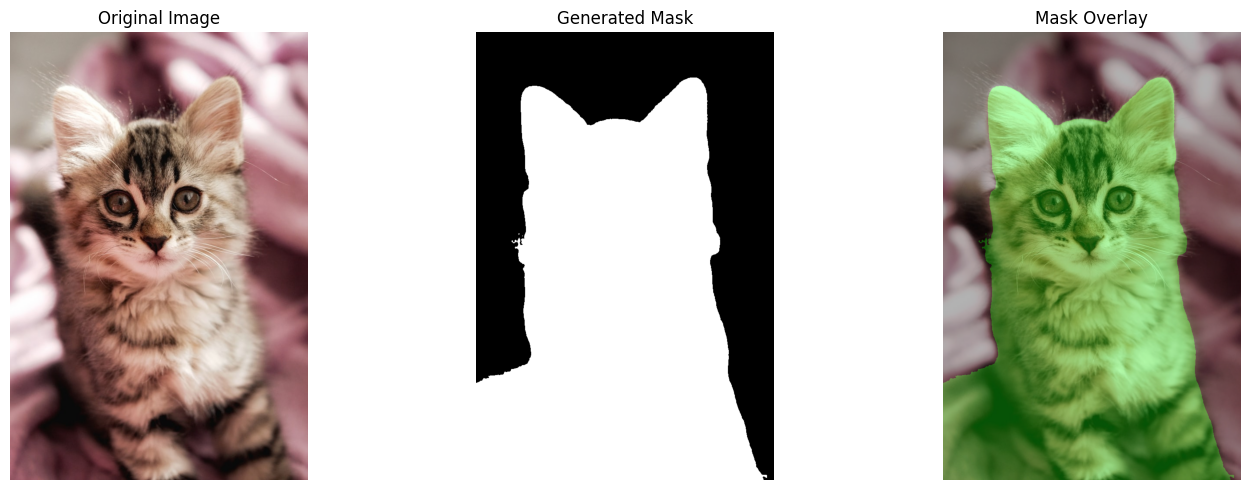

✓ Visualization complete!


In [17]:
import matplotlib.pyplot as plt

# Load the generated mask
mask = cv2.imread('./test_mask_output.png', cv2.IMREAD_GRAYSCALE)

# Create a visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(cat_img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Mask
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Generated Mask')
axes[1].axis('off')

# Overlay
overlay = cat_img_rgb.copy()
mask_colored = np.zeros_like(cat_img_rgb)
mask_colored[:, :, 1] = mask  # Green channel
overlay = cv2.addWeighted(overlay, 0.7, mask_colored, 0.3, 0)
axes[2].imshow(overlay)
axes[2].set_title('Mask Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")

## Cell 15: Test - Clear Memory

In [16]:
# Test clear memory endpoint
clear_response = requests.post(f'http://localhost:{PORT}/clear_memory')
print("Clear Memory Response:")
print(clear_response.json())

print(f"\n✓ All tests completed successfully!")
print(f"✓ Server is still running on http://localhost:{PORT}")

127.0.0.1 - - [30/Nov/2025 16:22:33] "POST /clear_memory HTTP/1.1" 200 -


Clear Memory Response:
{'message': 'Memory Cleared!'}

✓ All tests completed successfully!
✓ Server is still running on http://localhost:5000
